In [ ]:
import pandas as pd
import sqlite3

df = pd.read_csv('Superstore[1].csv', encoding='latin1')
df.columns = [c.replace(' ', '_').replace('-', '_') for c in df.columns]
conn = sqlite3.connect('superstore.db')
df.to_sql('orders', conn, if_exists='replace', index=False)
print("Veriler başarıyla SQL tablosuna aktarıldı.")

Veriler başarıyla SQL tablosuna aktarıldı.


In [17]:
# En çok satan kategorileri ve kar marjlarını buluyorum
query1 = """
SELECT 
    Category, 
    SUM(Sales) as Toplam_Satis, 
    SUM(Profit) as Toplam_Kar,
    (SUM(Profit) / SUM(Sales)) * 100 as Kar_Marji
FROM orders
GROUP BY Category
ORDER BY Toplam_Kar DESC;
"""
df_kategori = pd.read_sql_query(query1, conn)
df_kategori

,Category,Toplam_Satis,Toplam_Kar,Kar_Marji
0,Technology,836154.0330,145454.9481,17.395712
1,Office Supplies,719047.0320,122490.8008,17.035158
2,Furniture,741999.7953,18451.2728,2.486695


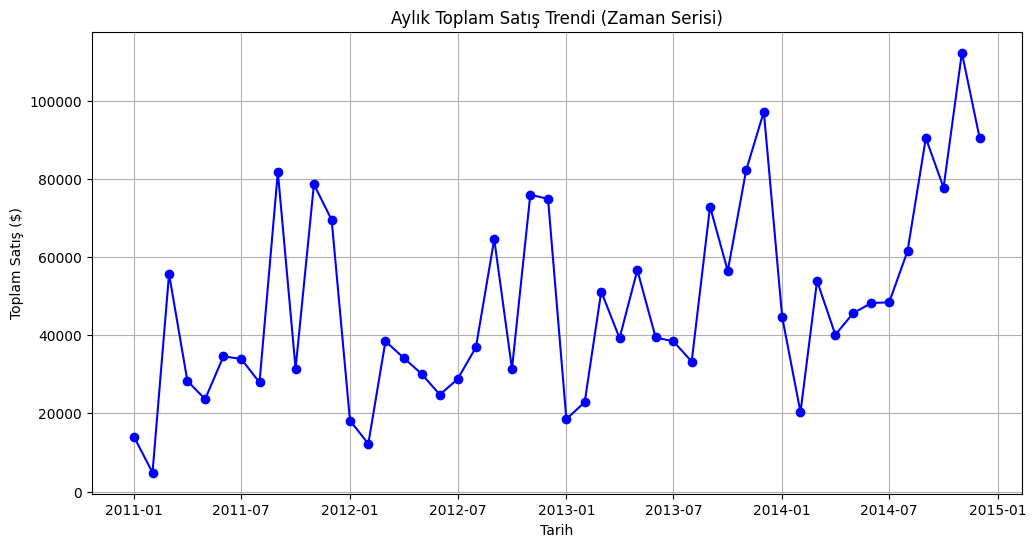

In [ ]:
import matplotlib.pyplot as plt

#SQL ile tarih ve satış verilerini çekiyorum
query_time = """
SELECT Order_Date, Sales FROM orders
"""
df_time = pd.read_sql_query(query_time, conn)

#Tarih sütununu'tarih' formatına çeviriyorum
#Veri setindeki tarih formatına göre (gün-ay-yıl) dönüştürüyorum
df_time['Order_Date'] = pd.to_datetime(df_time['Order_Date'], dayfirst=True)

#Verileri ay bazında grupluyorum
df_monthly = df_time.set_index('Order_Date').resample('MS').sum()

#Grafiğe döküyorum.
plt.figure(figsize=(12, 6))
plt.plot(df_monthly.index, df_monthly['Sales'], marker='o', linestyle='-', color='b')
plt.title('Aylık Toplam Satış Trendi (Zaman Serisi)')
plt.xlabel('Tarih')
plt.ylabel('Toplam Satış ($)')
plt.grid(True)
plt.show()

In [ ]:
# Tablo yapısını kontrol ediyorum
pd.read_sql("PRAGMA table_info(orders)", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,Row_ID,INTEGER,0,None,0
1,1,Order_ID,TEXT,0,None,0
2,2,Order_Date,TEXT,0,None,0
3,3,Ship_Date,TEXT,0,None,0
4,4,Ship_Mode,TEXT,0,None,0
5,5,Customer_ID,TEXT,0,None,0
6,6,Customer_Name,TEXT,0,None,0
7,7,Segment,TEXT,0,None,0
8,8,Country,TEXT,0,None,0
9,9,City,TEXT,0,None,0


In [ ]:
# En çok kar eden eyaletleri buluyorum
query2 = """
SELECT 
    State, 
    SUM(Profit) as Toplam_Kar
FROM orders
GROUP BY State
ORDER BY Toplam_Kar DESC
LIMIT 10;
"""
df_eyalet = pd.read_sql_query(query2, conn)
df_eyalet


,State,Toplam_Kar
0,California,76381.3871
1,New York,74038.5486
2,Washington,33402.6517
3,Michigan,24463.1876
4,Virginia,18597.9504
5,Indiana,18382.9363
6,Georgia,16250.0433
7,Kentucky,11199.6966
8,Minnesota,10823.1874
9,Delaware,9977.3748


In [ ]:
# Segment bazında ortalama indirim yüzdesini buluyorum
query3 = """
SELECT 
    Segment, 
    AVG(Discount) * 100 as Ortalama_Indirim_Yuzdesi
FROM orders
GROUP BY Segment;
"""
df_segment = pd.read_sql_query(query3, conn)
df_segment

,Segment,Ortalama_Indirim_Yuzdesi
0,Consumer,15.814101
1,Corporate,15.822848
2,Home Office,14.712844


In [ ]:
# İndirim oranlarına göre ortalama satış ve kâr durumunu sorguluyorum
query_discount = """
SELECT 
    Discount, 
    AVG(Sales) as Ort_Satis, 
    AVG(Profit) as Ort_Kar,
    COUNT(*) as Islem_Sayisi
FROM orders
GROUP BY Discount
ORDER BY Discount ASC;
"""
df_discount = pd.read_sql_query(query_discount, conn)
df_discount

,Discount,Ort_Satis,Ort_Kar,Islem_Sayisi
0,0.00,226.742074,66.900292,4798
1,0.10,578.397351,96.055074,94
2,0.15,529.971567,27.288298,52
3,0.20,209.076940,24.702572,3657
4,0.30,454.742974,-45.679636,227
5,0.32,536.794770,-88.560656,27
6,0.40,565.134874,-111.927429,206
7,0.45,498.634000,-226.646464,11
8,0.50,892.705152,-310.703456,66
9,0.60,48.150000,-43.077212,138


In [ ]:
# Alt kategori bazında en çok zarar ettiren ürünleri buluyorum
query_product = """
SELECT 
    Sub_Category, 
    SUM(Sales) as Toplam_Satis, 
    SUM(Profit) as Toplam_Kar,
    (SUM(Profit) / SUM(Sales)) * 100 as Kar_Yuzdesi
FROM orders
GROUP BY Sub_Category
ORDER BY Toplam_Kar ASC; -- En çok zarar ettirenden başlar
"""
df_product = pd.read_sql_query(query_product, conn)
df_product

,Sub_Category,Toplam_Satis,Toplam_Kar,Kar_Yuzdesi
0,Tables,206965.5320,-17725.4811,-8.564460
1,Bookcases,114879.9963,-3472.5560,-3.022768
2,Supplies,46673.5380,-1189.0995,-2.547695
3,Fasteners,3024.2800,949.5182,31.396504
4,Machines,189238.6310,3384.7569,1.788618
5,Labels,12486.3120,5546.2540,44.418672
6,Art,27118.7920,6527.7870,24.071083
7,Envelopes,16476.4020,6964.1767,42.267582
8,Furnishings,91705.1640,13059.1436,14.240358
9,Appliances,107532.1610,18138.0054,16.867517


In [ ]:
# Sadık müşterileri belirliyorum
query_loyalty = """
SELECT 
    Customer_ID, 
    Customer_Name, 
    COUNT(DISTINCT Order_ID) as Siparis_Sikligi,
    SUM(Sales) as Toplam_Harcama,
    AVG(Sales) as Siparis_Basina_Ortalama
FROM orders
GROUP BY Customer_ID
HAVING Siparis_Sikligi > 5
ORDER BY Toplam_Harcama DESC
LIMIT 10;
"""
df_loyalty = pd.read_sql_query(query_loyalty, conn)
df_loyalty

,Customer_ID,Customer_Name,Siparis_Sikligi,Toplam_Harcama,Siparis_Basina_Ortalama
0,RB-19360,Raymond Buch,6,15117.339,839.852167
1,AB-10105,Adrian Barton,10,14473.571,723.678550
2,KL-16645,Ken Lonsdale,12,14175.229,488.801000
3,SC-20095,Sanjit Chand,9,14142.334,642.833364
4,HL-15040,Hunter Lopez,6,12873.298,1170.299818
5,SE-20110,Sanjit Engle,11,12209.438,642.602000
6,TS-21370,Todd Sumrall,6,11891.751,792.783400
7,GT-14710,Greg Tran,11,11820.120,407.590345
8,SV-20365,Seth Vernon,10,11470.950,358.467188
9,CJ-12010,Caroline Jumper,8,11164.974,558.248700


In [ ]:
# Nakliye moduna göre ortalama gönderim süresini ve tercih edilme sıklığını analiz ediyorum
query_shipping = """
SELECT 
    Ship_Mode,
    AVG(julianday(substr(Ship_Date,7,4)||'-'||substr(Ship_Date,4,2)||'-'||substr(Ship_Date,1,2)) - 
        julianday(substr(Order_Date,7,4)||'-'||substr(Order_Date,4,2)||'-'||substr(Order_Date,1,2))) as Ort_Gonderim_Suresi,
    COUNT(*) as Tercih_Edilme_Sayisi
FROM orders
GROUP BY Ship_Mode;
"""
df_shipping = pd.read_sql_query(query_shipping, conn)
df_shipping

,Ship_Mode,Ort_Gonderim_Suresi,Tercih_Edilme_Sayisi
0,First Class,2.182055,1538
1,Same Day,0.044199,543
2,Second Class,3.240103,1945
3,Standard Class,5.007205,5968
